# FoodHub Portfolio Revision

# Takeaways
*  1,898 orders
*  39% unrated
*  Weekend 71% of volume
*  29% of orders over $20
*  Commission \$6,166.50
*  10.5% over 60 minutes
*  Four promo restaurants



### Context

The number of restaurants in New York keeps growing, and many of them take orders through delivery apps. FoodHub is an aggregator: one app, many kitchens. A customer orders, the restaurant confirms, and a courier handles pickup through drop-off. FoodHub earns a fixed margin on the order from the restaurant. Couriers earn a set percentage plus tips.

### Objective

Describe demand, ratings, cost tiers, and prep + delivery time so operations can target restaurants and hours that move revenue and experience.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [67]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
def glimpse(df):
#Glimpse
# The function glimpse takes a dataframe as a parameter and prints the shape and top, head and random rows

    print('glimpse shape...')
    print(f"{df.shape[0]} rows and {df.shape[1]} columns")
    print('glimpse head...')
    display(df.head(5))
    print('glimpse sample...')
    display(df.sample(5, replace=True))
    print('glimpse tail...')
    display(df.tail(5))

### Understanding the structure of the data

In [109]:
# Data file is colocated with this notebook (same folder).
# Public repo may omit the CSV; add foodhub_order.csv beside notebook.ipynb to run.
from pathlib import Path

IN_COLAB = True   # False when the notebook lives in C:\code\... with the CSV beside it

if IN_COLAB:
    from google.colab import drive
    mount = Path("/content/drive")
    if not (mount.exists() and any(mount.iterdir())):
        drive.mount("/content/drive")
    MyDataFile = Path("/content/drive/MyDrive/Colab Notebooks/foodhub_order.csv")
else:
    MyDataFile = Path("foodhub_order.csv")

if not MyDataFile.exists():
    raise FileNotFoundError(MyDataFile)

print("Loading", MyDataFile)
MyDataFile = str(MyDataFile)

Loading /content/drive/MyDrive/Colab Notebooks/foodhub_order.csv


In [110]:
# read the datafile into varable df
MyDataFile = Path("/content/drive/MyDrive/Colab Notebooks/foodhub_order.csv")
if not MyDataFile.exists():
    raise FileNotFoundError(MyDataFile)

print('Loading...' + str(MyDataFile))
df = pd.read_csv(MyDataFile)

# call the function glimpse passing the df object to inspect the data
glimpse(df)



Loading.../content/drive/MyDrive/Colab Notebooks/foodhub_order.csv
glimpse shape...
1898 rows and 9 columns
glimpse head...


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


glimpse sample...


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1201,1476676,186473,Blue Ribbon Sushi,Japanese,16.06,Weekday,Not given,34,33
644,1477678,102085,Otto Enoteca Pizzeria,Italian,9.61,Weekend,5,26,30
1031,1477176,260680,Tamarind TriBeCa,Indian,12.95,Weekday,3,27,24
702,1477017,175101,TAO,Japanese,15.76,Weekend,Not given,26,19
512,1477832,100778,Spice Thai,Thai,15.86,Weekend,Not given,34,25


glimpse tail...


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [71]:
#Generate a list of column names
#Loop through the columns of the dataset printing the column name

for col in df.columns:
    print(col)

order_id
customer_id
restaurant_name
cuisine_type
cost_of_the_order
day_of_the_week
rating
food_preparation_time
delivery_time


In [72]:
#Generate a list of location + column names
# Loop through the columns of the dataset printing the location (index) and column name

for col in df.columns:
    print( str(df.columns.get_loc(col)) + '\t' +col)

0	order_id
1	customer_id
2	restaurant_name
3	cuisine_type
4	cost_of_the_order
5	day_of_the_week
6	rating
7	food_preparation_time
8	delivery_time


#### Observations by Scott Horning :

*   The DataFrame has 9 columns as mentioned in the Data Dictionary.

*   Data in each row corresponds to the order placed by a customer.

*   There are 1,898 orders in the file.

*   There are 1,200 distinct customers.

*   Column *restaraunt_name* perhaps is contaminted by comments.


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [73]:
# Write your code here
# Return a tuple representing the dimensionality of the DataFrame.
display(df.shape)
print("There are", df.shape[0], 'rows and', df.shape[1], "columns.")


(1898, 9)

There are 1898 rows and 9 columns.


#### Observations  by Scott Horning:
There are 1,898 rows and 9 columns in the file foodhub_order.csv


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [74]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations by Scott Horning:
1. The file is small (133.6 kb ) memory. I expect no issues managing memory.
2. There are the following data types
  1. 1 *Float64* column : cost_of_the_order
  2. 4 *int64* columns : *delivery_time*, *food_preparation_time*, *customer_id* and *order_id*.   
  3. 4 *Object* columns : *rating*, *day_of_the_week*, cuisine_type and *restaurant_name*
  4. There are 1,898 records / observations
  5. The index is zero based

  For the int64 varibles I suspect that *customer_id* should be an object varible as it leads back to a customer dimention.

  For the float Varibles ( cost_of_the_order ) no changes. United States currency is a decimal

  For the Object Varibles the column *rating* is a canidate to cast as an int.




### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [75]:
# checking missing values across each columns
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations by Scott Horning :
*   Each record has a complete set of values...  no nulls.
*   For the field **rating** ... orders with no customer supplied values are defaulted to the string literal 'Not given'




### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [76]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations by Scott Horning:
What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?
1. min of *food_preparation_time* is 20 minutes :
The minimum time it takes for food to be prepared once an order is placed is 20 minutes.

2. mean of *food_preparation_time* is 27.37197 minutes :
The average time is 27.37197 minutes ( approx 27 minutes and 24 seconds )

3. max of *food_preparation_time* is 35 minutes :
The maximum time it takes for food to be prepared once an order is placed is 35 minutes.




### **Question 5:** How many orders are not rated? [1 mark]

In [77]:
# Find the categorical values of rating
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [78]:
# count order for each category
df.groupby(['rating'])['order_id'].count()

,order_id
rating,
3,188
4,386
5,588
Not given,736


#### Observations by Scott Horning
We can see that the range of object values for the column *rating* is 'Not given', '5', '3', '4'

How many orders are not rated? 736 orders are not rated.


In [79]:
# customer_id is behaves like a government id ( ssn, dl# ect... ) because it represents a customer
# make it a string

NewCol = df['customer_id'].astype(str)
df['customer_id'] = NewCol
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   object 
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 133.6+ KB


In [80]:
# order_id is behaves like a government id ( ssn, dl# ect... ) because it represents an order
# make it a string

NewCol = df['order_id'].astype(str)
df['order_id'] = NewCol
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   object 
 1   customer_id            1898 non-null   object 
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 133.6+ KB


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

####order_id observations :
*    order_id is a unique sequential interger that identifies the an order.
* There are 1,898 orders in the datafile
---
code below

In [81]:
print('Varible name is order_id'   )
print('df[\'order_id\'].is_unique = ' + str( df['order_id'].is_unique))
df['order_id'].describe().T






Varible name is order_id
df['order_id'].is_unique = True


,order_id
count,1898
unique,1898
top,1478056
freq,1


####customer_id observations :
*    customer_id is an interger that identifies the customers.
*    There are 1,898 orders in the datafile amd 1,200 distinct cusomters
*    25% of the customers (300) ordered at least twice
*    the top 5 customers had 7,8,9,10 and 13 orders


---
code below

customer_id
df['customer_id'].is_unique = False
          order_id
count  1200.000000
mean      1.581667
std       1.090560
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      13.000000
Boxplot  


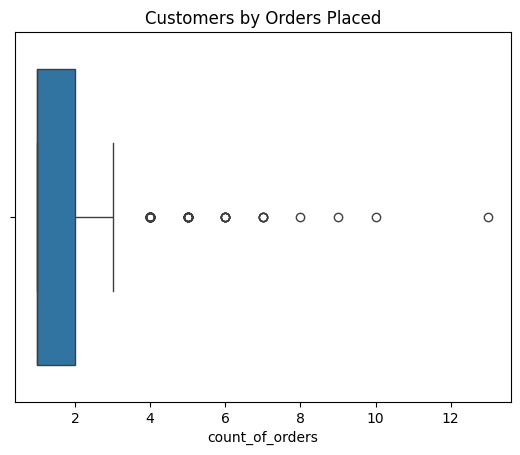

,customer_id,count_of_orders
879,52832,13
846,47440,10
1100,83287,9
411,250494,8
981,65009,7
419,259341,7
1096,82041,7
444,276192,7
1193,97991,6
936,60052,6


In [82]:
# Aggregate orders by count to customer_id


print('customer_id')
print('df[\'customer_id\'].is_unique = ' + str( df['customer_id'].is_unique))
p_table = df.pivot_table(
                         index=['customer_id']
                         , values=['order_id']
                         , aggfunc='count' )
p_table.reset_index(inplace=True)

print(p_table.describe())

sorted_df = p_table.rename(columns={'order_id': 'count_of_orders','customer_id': 'customer_id'})
sorted_df = sorted_df.sort_values(by=['count_of_orders'], ascending=False)

print('Boxplot  ')
sns.boxplot(data=sorted_df,x='count_of_orders').set(title='Customers by Orders Placed');
plt.show()
sorted_df





####restaurant_name observations :
*    The field Data has data Quality Issues
*    We started with 178 unique names
*    restartaunt *dirty Bird* to go needed trim of trailing char and
a the application of tile case leading to 177 restariaount names


> 1. 5 restaraunts begin with the string *Blue Ribbon*
> 2.    2 restaraunts that begin with *Red Farm*
> 3.    4 restaraunts that begin with *Sarabeths*
> 4.   5 restaraunts that begin with *Sushi*
> 5.  2 restaraunts that begin with *Vanessas*Indented block





*    there are inconsistent values in restaraunt name
    - mixed fields, typeo's and other errors may cause the same restaraunt split over a groupby statement.
*   *ilili Restaurant* appears to be entry error

* Shake shack is the most popular restaraunt with 219 orders
* The distribution is right skewed
* On average a restaraunt has 88 orders



---
code follows below

In [83]:

# Junk char in the restaruant name field
# Keep only ascii
# drop text 199 Delivery
# return the 'e' to Caf China
# continue to clean suspicious...
NewCol = df['restaurant_name'].astype(str).replace('[^a-zA-Z0-9 ]', '', regex=True)
NewCol = NewCol.replace('Caf China', 'Cafe China')
NewCol = NewCol.replace('Chipotle Mexican Grill 199 Delivery', 'Chipotle Mexican Grill')
NewCol = NewCol.replace('Empanada Mama closed', 'Empanada Mama')
NewCol = NewCol.replace('Dirty Bird To Go archived', 'Dirty Bird To Go')
NewCol = NewCol.replace('Dirty Bird to Go', 'Dirty Bird To Go')

df['restaurant_name'] = NewCol
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   object 
 1   customer_id            1898 non-null   object 
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 133.6+ KB


restaurant_name
df['restaurant_name'].is_unique = False
count    177.000000
mean      10.723164
std       24.104582
min        1.000000
25%        1.000000
50%        3.000000
75%        9.000000
max      219.000000
Name: counts, dtype: float64


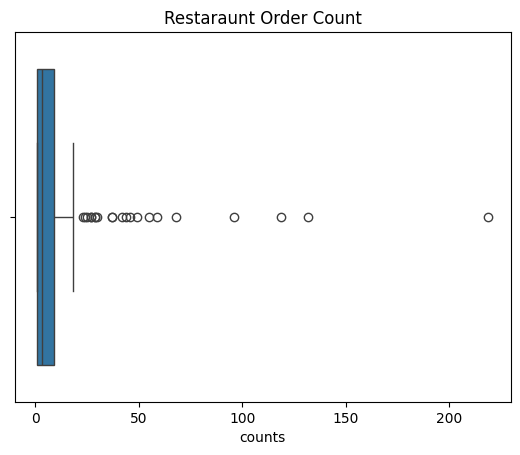

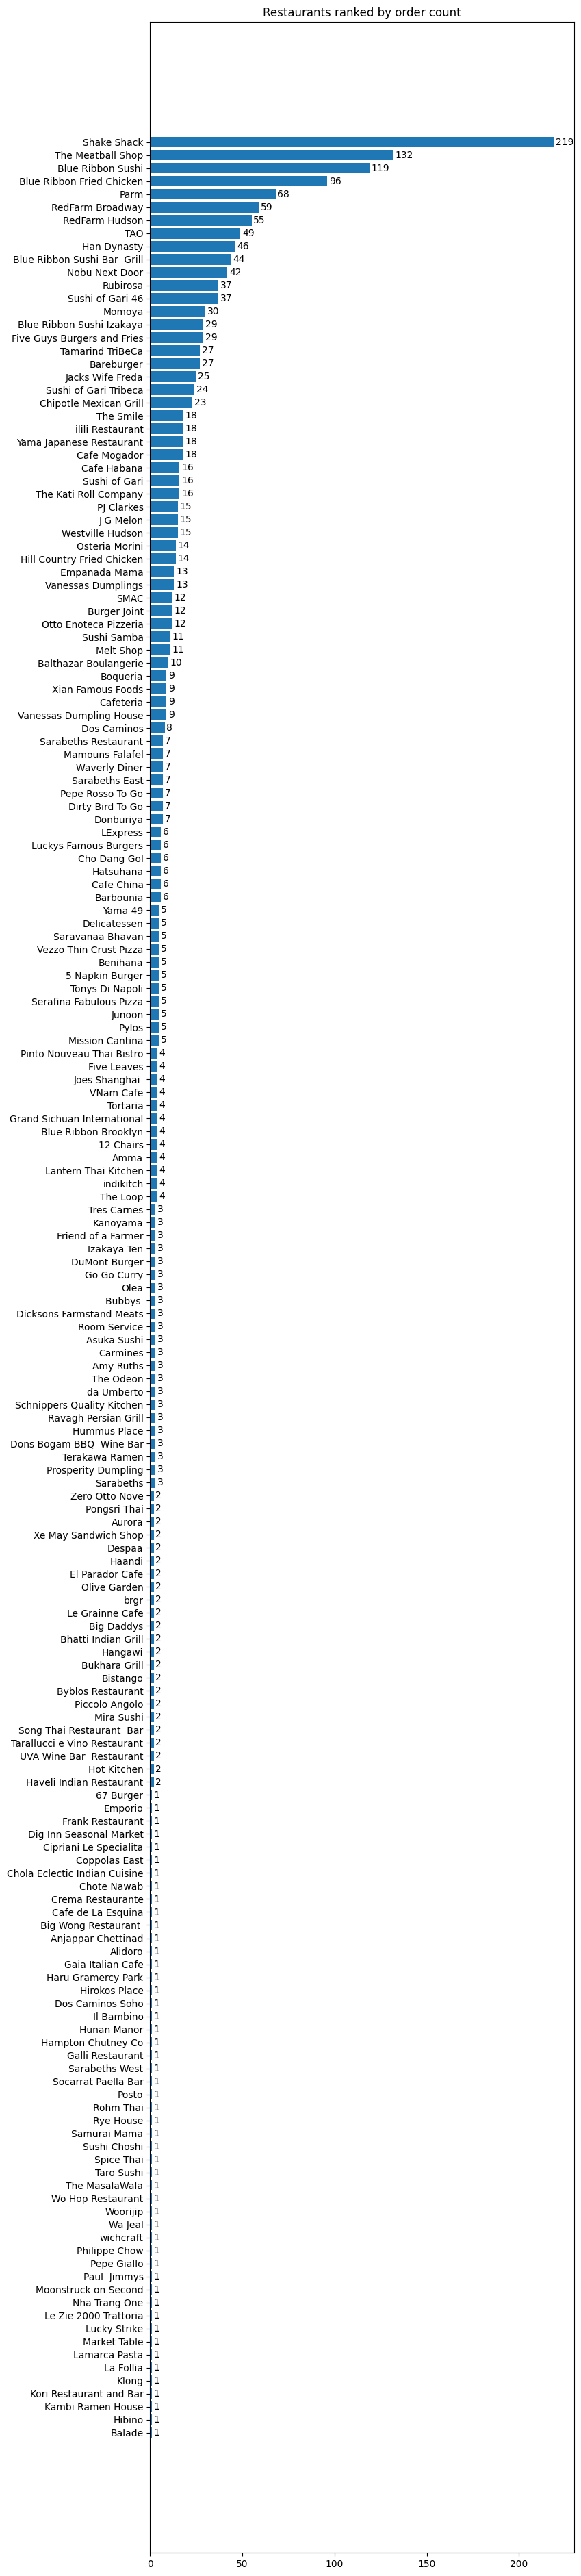

,restaurant_name,counts
134,Shake Shack,219
151,The Meatball Shop,132
20,Blue Ribbon Sushi,119
19,Blue Ribbon Fried Chicken,96
107,Parm,68


In [84]:
# Write the code here
## Aggregate orders by count to customer_id using a pivot_table and sort
pd.options.display.max_columns = None
pd.options.display.max_rows = None


sorted_df=df.groupby(['restaurant_name'])['order_id'].count().reset_index(name='counts')
sorted_df=sorted_df.sort_values(by=['counts'], ascending=False)
# sorted_df=sorted_df.reset_index()


print('restaurant_name')
print('df[\'restaurant_name\'].is_unique = ' + str( df['restaurant_name'].is_unique))
print(sorted_df['counts'].describe().T)


sns.boxplot(data=sorted_df,x='counts').set_title('Restaraunt Order Count')
plt.show()


sorted_df=sorted_df.sort_values(by=['counts'], ascending=True)
# Initialize a Figure and an Axes
fig, ax = plt.subplots()

# Fig size
fig.set_size_inches(8,48)
# sns.set(font_scale=1)

# Create horizontal bars
ax.barh(y=sorted_df.restaurant_name, width=sorted_df.counts);

# Add title
ax.set_title('Restaurants ranked by order count');

for p in ax.patches:
    width = p.get_width()    # get bar length
    ax.text(width + 1,       # set the text at 1 unit right of the bar
            p.get_y() + p.get_height() / 2, # get Y coordinate + X coordinate / 2
            # '{:1.2f}'.format(width), # set variable to display, 2 decimals
            '{:1}'.format(width), # set variable to display, 2 decimals
            ha = 'left',   # horizontal alignment
            va = 'center')  # vertical alignmen
plt.show()
sorted_df=sorted_df.sort_values(by=['counts'], ascending=False)
sorted_df.head(5)





####cuisine_type observations :
*  There are 14 cuisine_types
*  The 82.5% of orders are  American , Japenese , Italian 0r Chinese.
*  The data is right skewed.



---
code follows below

cuisine_type
df['cuisine_type'].is_unique = False
  cuisine_type  counts
0     American     584
5     Japanese     470
4      Italian     298
1      Chinese     215
8      Mexican      77
           counts
count   14.000000
mean   135.571429
std    187.448748
min      7.000000
25%     17.250000
50%     47.500000
75%    180.500000
max    584.000000


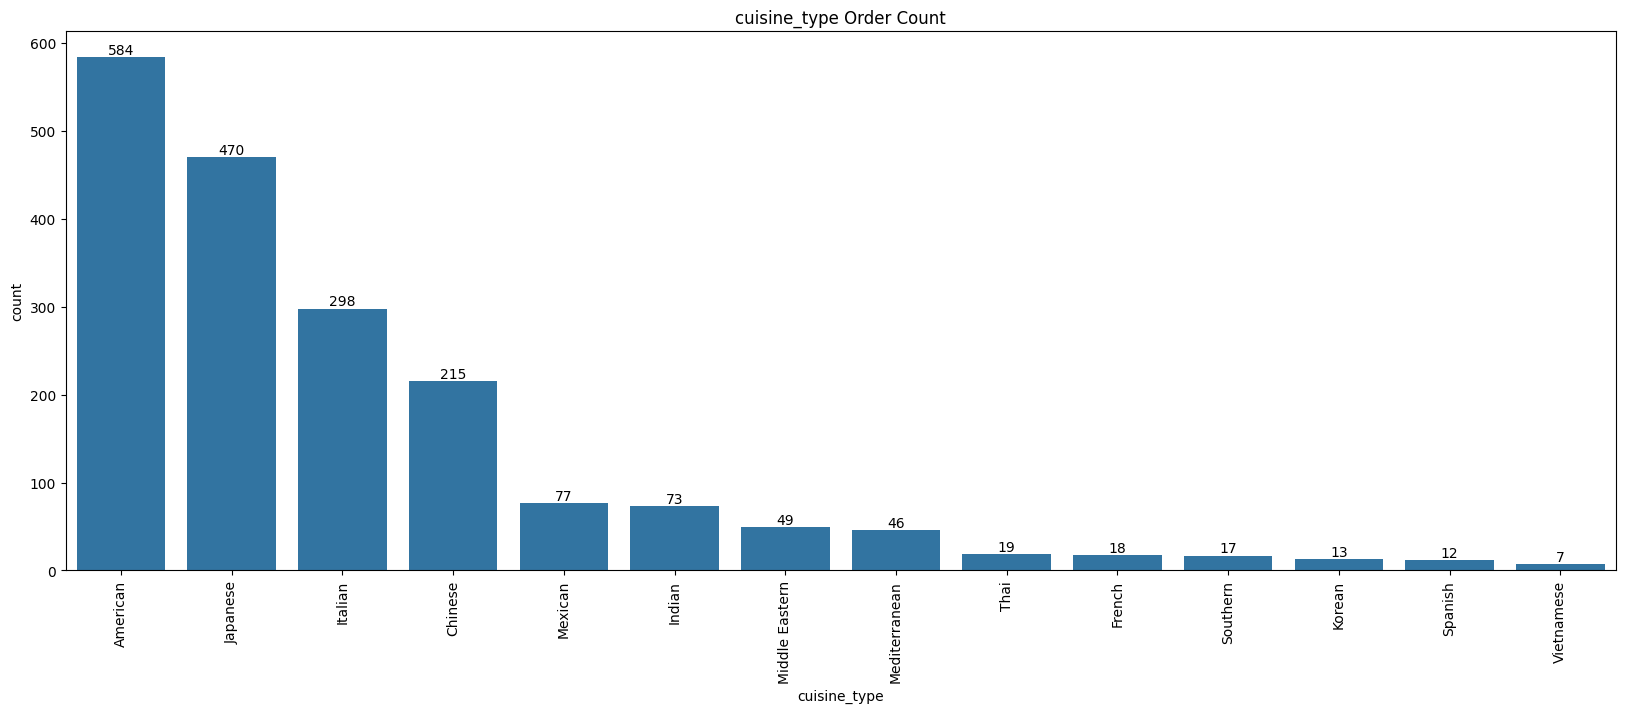

,cuisine_type,counts
0,American,584
5,Japanese,470
4,Italian,298
1,Chinese,215
8,Mexican,77
3,Indian,73
9,Middle Eastern,49
7,Mediterranean,46
12,Thai,19
2,French,18


In [85]:

pd.options.display.max_columns = None
pd.options.display.max_rows = None


sorted_df=df.groupby(['cuisine_type'])['order_id'].count().reset_index(name='counts')
sorted_df=sorted_df.sort_values(by=['counts'], ascending=False)

print('cuisine_type')
print('df[\'cuisine_type\'].is_unique = ' + str( df['cuisine_type'].is_unique))
print(sorted_df.head())
print(sorted_df.describe())


plt.figure(figsize=(20,7))

ax = sns.countplot(data=df, x='cuisine_type', order=df['cuisine_type'].value_counts().index)
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title('cuisine_type Order Count')
plt.xticks(rotation=90);
plt.show()
sorted_df

####cost_of_the_order observations :
*    cost_of_the_order
*    Average order cost is \$16.99
*    Range is \$4.47 to \$35.41
*    The distribution is bi-modal..
*    orders tend to bucket in three categories/ranges :20, 20 to 30 , >30
---
code below


 Check the counts


,cost_of_the_order
count,1898.000000
mean,16.498851
std,7.483812
min,4.470000
25%,12.080000
50%,14.140000
75%,22.297500
max,35.410000


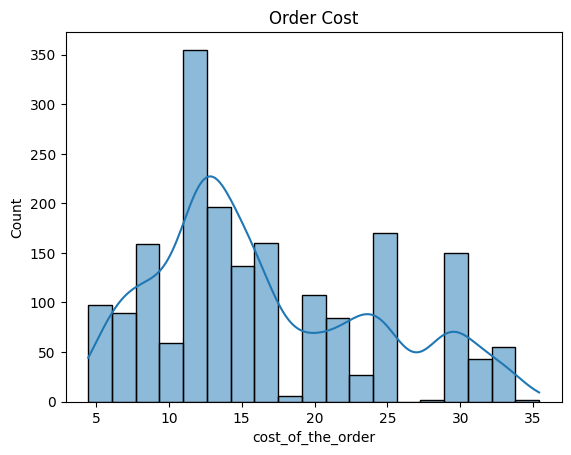

In [86]:
# df['cost_of_the_order'].info()
df['cost_of_the_order'].describe()
print('\n Check the counts')
# print(df.groupby(['cost_of_the_order'])['order_id'].count())

sns.histplot(data=df, x='cost_of_the_order', kde=True).set(title='Order Cost')
df['cost_of_the_order'].describe()

####day_of_the_week observations :
*    day_of_the_week
*    weekday is 5 days monday to Friday
*    weekend is Sat and Sun
*    71% (1,351/1,898) of orders are on weekend


---
code follows below

<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: day_of_the_week
Non-Null Count  Dtype 
--------------  ----- 
1898 non-null   object
dtypes: object(1)
memory usage: 15.0+ KB

 Check the counts
day_of_the_week
Weekday     547
Weekend    1351
Name: order_id, dtype: int64


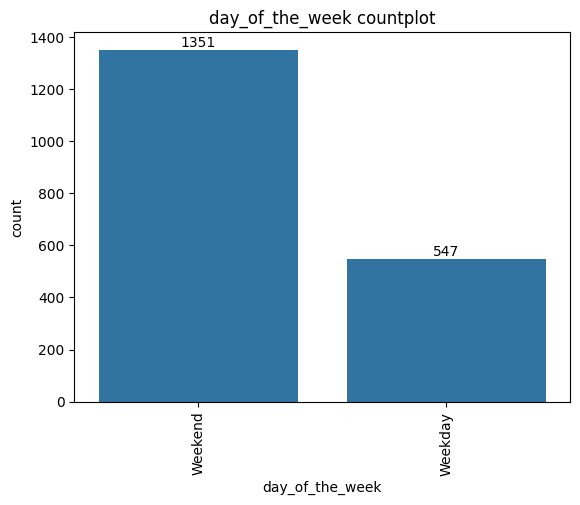

0.7118018967334035


In [87]:
df['day_of_the_week'].info()
print('\n Check the counts')
print(df.groupby(['day_of_the_week'])['order_id'].count())

ax = sns.countplot(data=df, x='day_of_the_week', order=df['day_of_the_week'].value_counts().index)
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title('day_of_the_week countplot')
plt.xticks(rotation=90);
plt.show()
print ( 1351/1898)

####rating observations :
*    39% of ratings are not provided
*    10% of ratings are a 3
*    51% of ratings are 4 or 5
*    Need to lift ratings ( make 3 ratings 4 or 5 )
*    Need to reduce the number of non raters
*    Categorical varible needs to be cast as int for calulating average score


---
code below

<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: rating
Non-Null Count  Dtype 
--------------  ----- 
1898 non-null   object
dtypes: object(1)
memory usage: 15.0+ KB

 Check the counts


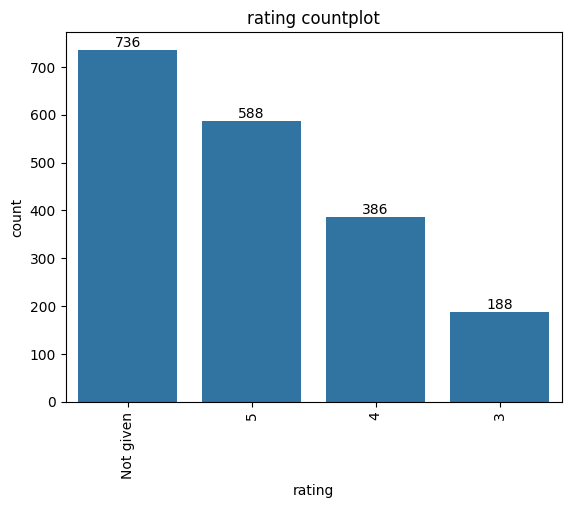

,percentage,count
rating,,
3,9.905163,188
4,20.337197,386
5,30.979979,588
Not given,38.777661,736


In [88]:
df['rating'].info()
print('\n Check the counts')
df1=(df.groupby(['rating'])['order_id'].count()/1898*100)
df2=(df.groupby(['rating'])['order_id'].count())
df3 = pd.merge(df1,df2,on='rating').rename(columns={'order_id_x': 'percentage', 'order_id_y': 'count'})

ax = sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title('rating countplot')
plt.xticks(rotation=90);
plt.show()

df3

####food_preparation_time observations :
*    food_preparation_time is on average 27 minutes per order.
*    This seems high from personal experience.
*    We should look at ways to reduce this varible
*    We should look for cooralations to rating and deliver time


---
code below

<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: food_preparation_time
Non-Null Count  Dtype
--------------  -----
1898 non-null   int64
dtypes: int64(1)
memory usage: 15.0 KB
count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64


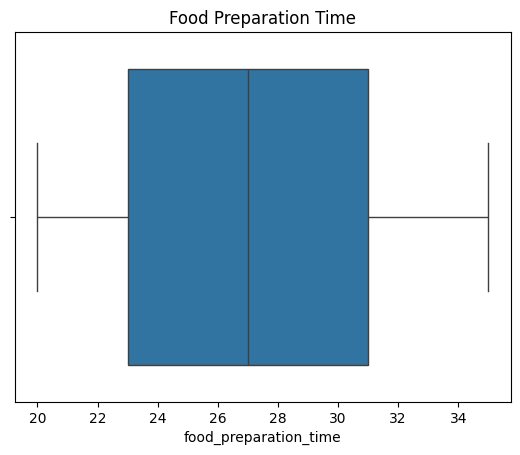

In [89]:
df['food_preparation_time'].info()

print(df['food_preparation_time'].describe())

sns.boxplot(data=df,x='food_preparation_time').set(title='Food Preparation Time');

####delivery_time observations :
*    delivery_time is on average 25 minutes per order.
*    This seems high from personal experience.
*    We should look at ways to reduce this varible
*    We should look for cooralations to rating and deliver time

---
code below


<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: delivery_time
Non-Null Count  Dtype
--------------  -----
1898 non-null   int64
dtypes: int64(1)
memory usage: 15.0 KB
count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64


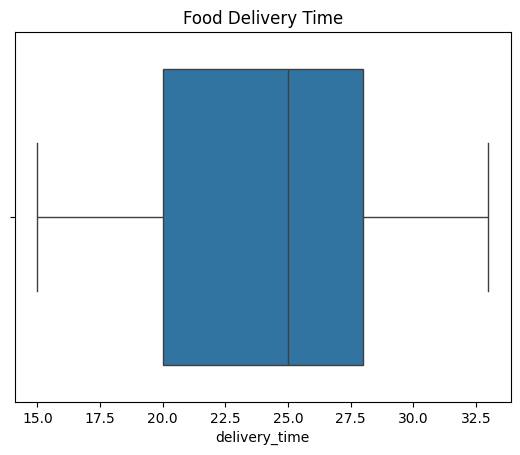

In [90]:
df['delivery_time'].info()

print(df['delivery_time'].describe())

sns.boxplot(data=df,x='delivery_time').set(title='Food Delivery Time');

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

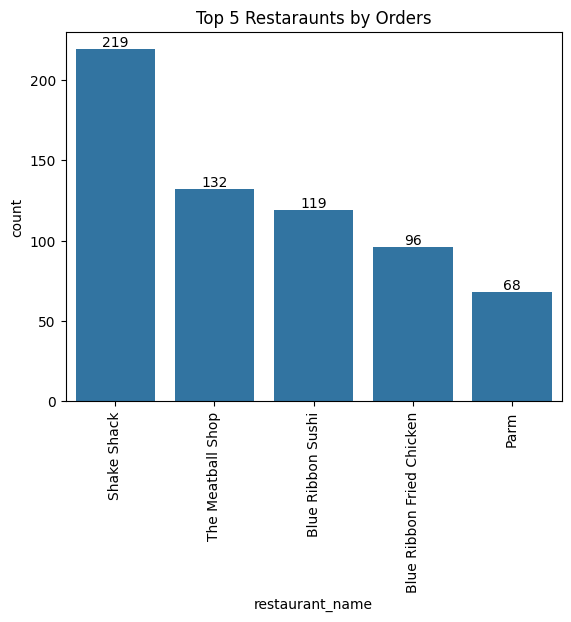

Top 5 Restaraunts by Orders


,index,restaurant_name,order_count,percent_of_orders
0,134,Shake Shack,219,11.538462
1,151,The Meatball Shop,132,6.954689
2,20,Blue Ribbon Sushi,119,6.269758
3,19,Blue Ribbon Fried Chicken,96,5.057956
4,107,Parm,68,3.582719


In [91]:
# Write the code here
## Aggregate orders by count to customer_id using a pivot_table and sort
pd.options.display.max_columns = None
pd.options.display.max_rows = None


sorted_df=df.groupby(['restaurant_name'])['order_id'].count().rename("order_count").reset_index(name='order_count')
sorted_df=sorted_df.sort_values(by=['order_count'], ascending=False)
sorted_df=sorted_df.reset_index()
temp_df=df.groupby('restaurant_name')['order_id'].count().rename("percentage").transform(lambda x:100 * ( x/x.sum())).reset_index(name='order_count')
df3 = pd.merge(sorted_df, temp_df, on='restaurant_name')
sorted_df = df3.rename(columns={'order_count_y': 'percent_of_orders', 'order_count_x': 'order_count'})


ax = sns.countplot(data=df, x='restaurant_name', order=df['restaurant_name'].value_counts().iloc[:5].index)
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title('Top 5 Restaraunts by Orders')
plt.xticks(rotation=90);
plt.show()

# sorted_df=sorted_df.head(5).sort_values(by=['order_count'], ascending=False)
print('Top 5 Restaraunts by Orders')


sorted_df.head(5)

#### Observations: Shake Shack is the most popular restaraunt with 11.5% (219) share of ordera. A distant second is The meayball Shop at 7% (132) then Blue Ribbon Sushi at 6.3%(119) of orders. Blue Ribbon Fried Chicken and Parm are 4th and 5th with 5.0%(96) and 3.5%(68) of the orders respectively.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

cuisine_type
df['cuisine_type'].is_unique = False
  cuisine_type  counts
0     American     415
5     Japanese     335
4      Italian     207
1      Chinese     163
8      Mexican      53
           counts
count   14.000000
mean    96.500000
std    133.453391
min      4.000000
25%     11.500000
50%     32.000000
75%    135.500000
max    415.000000


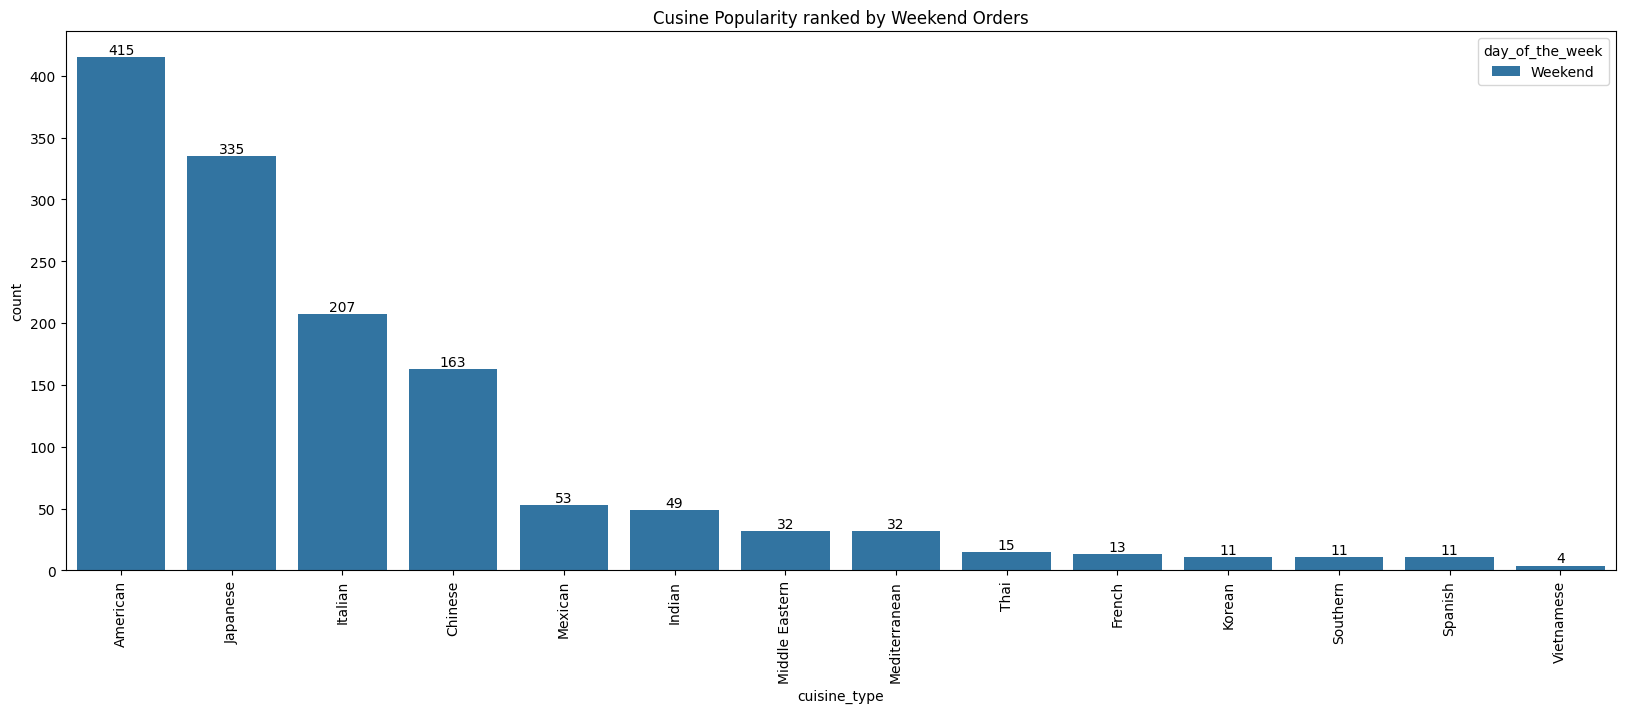

,cuisine_type,counts
0,American,415
5,Japanese,335
4,Italian,207
1,Chinese,163
8,Mexican,53
3,Indian,49
9,Middle Eastern,32
7,Mediterranean,32
12,Thai,15
2,French,13


In [92]:

pd.options.display.max_columns = None
pd.options.display.max_rows = None
temp_df = df[df['day_of_the_week'].str.contains('Weekend')]

sorted_df=temp_df.groupby(['cuisine_type'])['order_id'].count().reset_index(name='counts')
sorted_df=sorted_df.sort_values(by=['counts'], ascending=False)
sorted_df.reset_index()
print('cuisine_type')
print('df[\'cuisine_type\'].is_unique = ' + str( df['cuisine_type'].is_unique))
print(sorted_df.head())
print(sorted_df.describe())


plt.figure(figsize=(20,7))

ax = sns.countplot(data=temp_df, x='cuisine_type',hue='day_of_the_week', order=temp_df['cuisine_type'].value_counts().index)
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title('Cusine Popularity ranked by Weekend Orders')
plt.xticks(rotation=90);
plt.show()
sorted_df

#### Observations: American is the most popular weekend cuisine with 30.7%  of the weekwnd orders (415/1351)


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [93]:

# Make a  column called Greater Than $20 (greater_than_20) to calculate
#   25% on the orders having cost greater than 20 dollars
#   15% on the orders having cost greater than 5 dollars
# if cost_of_the_order >$20 then  cost_of_the_order * .25
# else if cost_of_the_order >$5 and cost_of_the_order <=$20 then then  cost_of_the_order * .15
# else 0
def gt20(cost):
  if cost>20 :
     rtn=' Greater Than $20.00'
  else :
     rtn=' Less Than Equal to $20.00'
  return rtn

NewCol = df['cost_of_the_order'].apply(gt20)
df['cost_greater_than_20'] = NewCol
df.info()
glimpse(df[['cost_of_the_order','cost_greater_than_20']])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   object 
 1   customer_id            1898 non-null   object 
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   cost_greater_than_20   1898 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 148.4+ KB
glimpse shape...
1898 rows and 2 columns
glimpse head...


,cost_of_the_order,cost_greater_than_20
0,30.75,Greater Than $20.00
1,12.08,Less Than Equal to $20.00
2,12.23,Less Than Equal to $20.00
3,29.20,Greater Than $20.00
4,11.59,Less Than Equal to $20.00


glimpse sample...


,cost_of_the_order,cost_greater_than_20
1134,9.41,Less Than Equal to $20.00
473,13.92,Less Than Equal to $20.00
1172,29.05,Greater Than $20.00
152,33.03,Greater Than $20.00
1704,12.47,Less Than Equal to $20.00


glimpse tail...


,cost_of_the_order,cost_greater_than_20
1893,22.31,Greater Than $20.00
1894,12.18,Less Than Equal to $20.00
1895,25.22,Greater Than $20.00
1896,12.18,Less Than Equal to $20.00
1897,19.45,Less Than Equal to $20.00


<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: cost_greater_than_20
Non-Null Count  Dtype 
--------------  ----- 
1898 non-null   object
dtypes: object(1)
memory usage: 15.0+ KB

 Check the counts
cost_greater_than_20
Greater Than $20.00           555
Less Than Equal to $20.00    1343
Name: order_id, dtype: int64


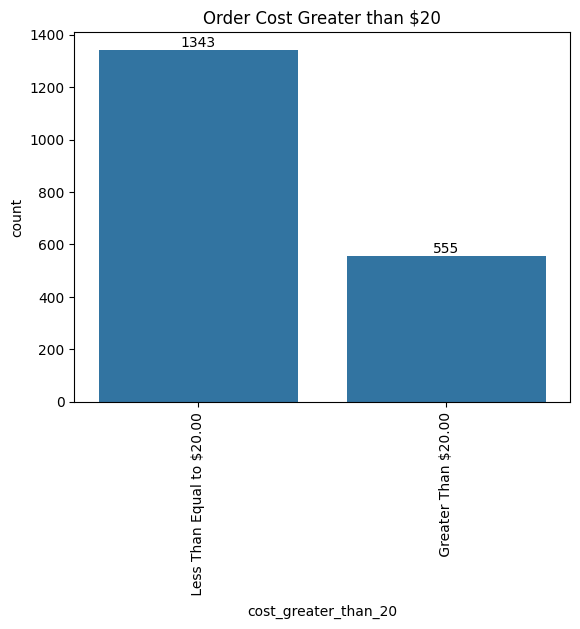

,index,cost_greater_than_20,order_count,percent_of_orders
0,1,Less Than Equal to $20.00,1343,70.758693
1,0,Greater Than $20.00,555,29.241307


In [94]:
df['cost_greater_than_20'].info()
print('\n Check the counts')
print(df.groupby(['cost_greater_than_20'])['order_id'].count())

ax = sns.countplot(data=df, x='cost_greater_than_20', order=df['cost_greater_than_20'].value_counts().index)
ax.bar_label(ax.containers[0], label_type='edge')
ax.set_title('Order Cost Greater than $20')
plt.xticks(rotation=90);
plt.show()

sorted_df=df.groupby(['cost_greater_than_20'])['order_id'].count().rename("order_count").reset_index(name='order_count')
sorted_df=sorted_df.sort_values(by=['order_count'], ascending=False)
sorted_df=sorted_df.reset_index()
temp_df=df.groupby('cost_greater_than_20')['order_id'].count().rename("percentage").transform(lambda x:100 * ( x/x.sum())).reset_index(name='order_count')
df3 = pd.merge(sorted_df, temp_df, on='cost_greater_than_20')
sorted_df = df3.rename(columns={'order_count_y': 'percent_of_orders', 'order_count_x': 'order_count'})
sorted_df



#### Observations

**29% (555)** of orders cost **more than \$20**.  

**71% (1,343)** cost \$20 or less.

The 25% commission tier is the smaller slice. Most tickets sit in the 15% band.

This 71% is *not* the weekend-volume 71% (1,351 / 1,898). Same percentage, different cut.

### **Question 10**: What is the mean order delivery time? [1 mark]

The mean delivery time is...  24.161749209694417


,delivery_time
count,1898.000000
mean,24.161749
std,4.972637
min,15.000000
25%,20.000000
50%,25.000000
75%,28.000000
max,33.000000


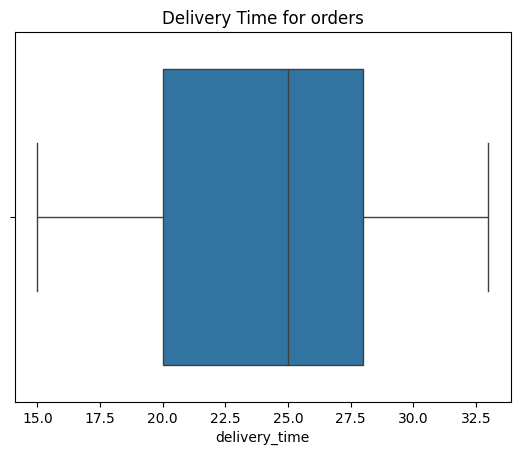

In [95]:
print('The mean delivery time is... ' , df['delivery_time'].mean())
sns.boxplot(data=df,x='delivery_time').set(title='Delivery Time for orders');
df['delivery_time'].describe()

#### Observations: On average delivery time takes 25 minutes


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [96]:

sorted_df=df.groupby(['customer_id'])['order_id'].count().rename("order_count").reset_index(name='order_count')
sorted_df=sorted_df.sort_values(by=['order_count'], ascending=False)
sorted_df=sorted_df.reset_index()
temp_df=df.groupby('customer_id')['order_id'].count().rename("percentage").transform(lambda x:100 * ( x/x.sum())).reset_index(name='order_count')
df3 = pd.merge(sorted_df, temp_df, on='customer_id')
sorted_df = df3.rename(columns={'order_count_y': 'percent_of_orders', 'order_count_x': 'order_count'})
sorted_df.head(3)

,index,customer_id,order_count,percent_of_orders
0,879,52832,13,0.684932
1,846,47440,10,0.526870
2,1100,83287,9,0.474183


#### Observations: The three customers eligible for the 20% voucher are customers  52832, 47440 and 83287.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [97]:

# Cast Rating as an int64 and
# make text fields 'NaN' by using the coerce optional parameter

# show it is data type object
# print('Check the data type')
df['rating'].info()



<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: rating
Non-Null Count  Dtype 
--------------  ----- 
1898 non-null   object
dtypes: object(1)
memory usage: 15.0+ KB


In [98]:
NewCol = pd.to_numeric(df['rating'], errors='coerce').astype('Int64')
df['rating_int64'] = NewCol
df['rating_int64'].value_counts()

,count
rating_int64,
5,588
4,386
3,188


In [99]:
# #change the data type to int64


print(df.groupby(['rating_int64'])['order_id'].count())
print(df.groupby(['rating'])['order_id'].count())

rating_int64
3    188
4    386
5    588
Name: order_id, dtype: int64
rating
3            188
4            386
5            588
Not given    736
Name: order_id, dtype: int64


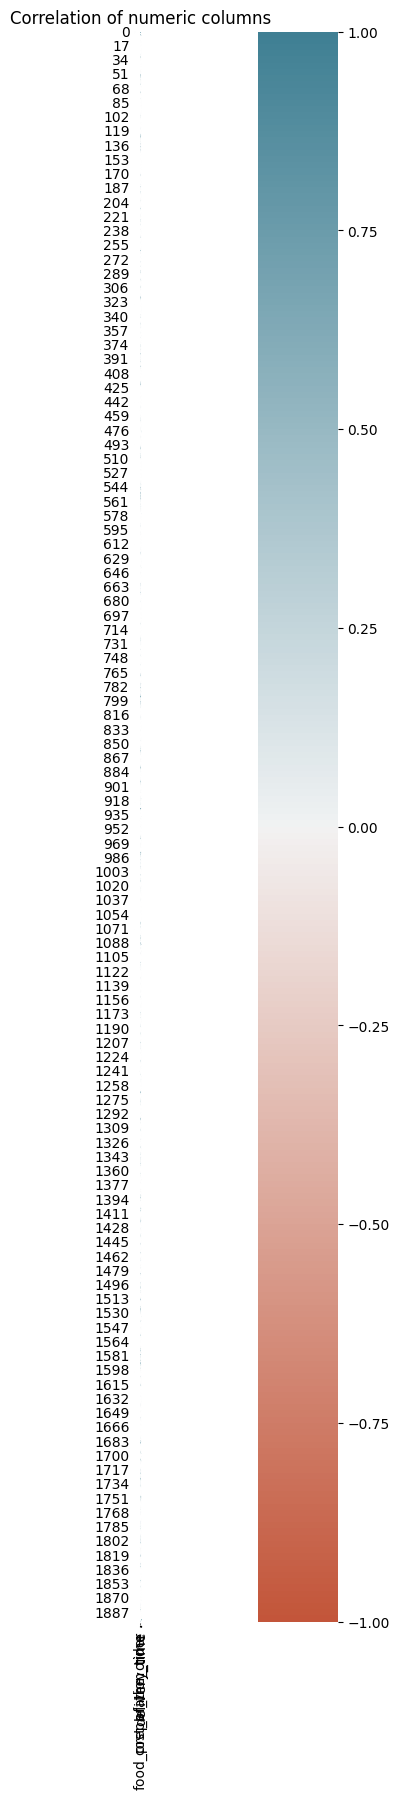

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [100]:
#Make Correlation Plot to explore relationships with numeric varibles
import warnings
warnings.filterwarnings('ignore')

f,ax = plt.subplots(figsize=(30, 30))
plt.subplots_adjust(bottom=0.35)
plt.autoscale()


corr_data = df[['cost_of_the_order', 'food_preparation_time', 'delivery_time']]
sns.heatmap(corr_data,
            annot=True,
            mask=np.zeros_like(corr_data, dtype=bool),
            cmap=sns.diverging_palette(20, 220, as_cmap=True),
            vmin=-1, vmax=1,
            square=True,
            ax=ax)
ax.set_title('Correlation of numeric columns')
plt.show()
warnings.filterwarnings(action='once')

#### Observations:
For the numeric columns we see week Correlation as no correlation is greater than .1
1. The strongest positive correlation revealed is a positive correlation between cost of the order and food prep time(.042).
2. The 2d strongest positive correlation is between rating and cost of the order (.034)
3. The 3d strongest positive correlation food preparation time and delivery time (.011)

1. The strongest negitive correlation revealed is a negitive correlation between cost of the order and delivery time(-.03).
2. The 2d strongest negitive correlation is between rating and delivery time(-0.0098)
3. The 3d strongest negitive correlation is between rating and food prep time(-0.0061)

Overall the correlations are weak but they are there. It is worth noting that rating is missing a full 39% of customer responses and correlations are directional only.


cuisine_type
cuisine_type  and  delivery_time


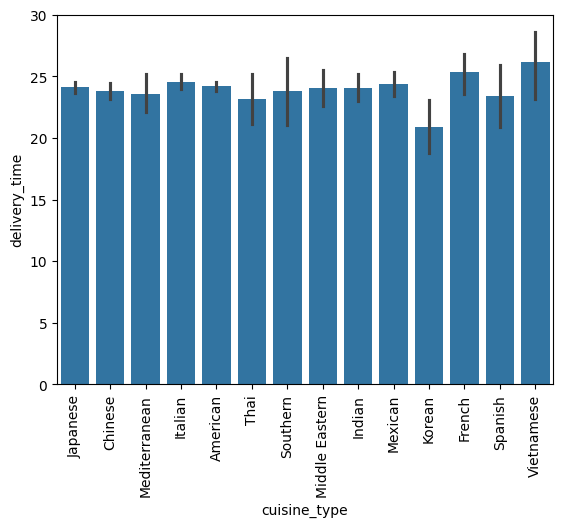

               delivery_time                  
                       count       mean    sum
cuisine_type                                  
American                 584  24.193493  14129
Chinese                  215  23.855814   5129
French                    18  25.333333    456
Indian                    73  24.082192   1758
Italian                  298  24.567114   7321
Japanese                 470  24.131915  11342
Korean                    13  20.923077    272
Mediterranean             46  23.586957   1085
Mexican                   77  24.389610   1878
Middle Eastern            49  24.081633   1180
Southern                  17  23.823529    405
Spanish                   12  23.416667    281
Thai                      19  23.157895    440
Vietnamese                 7  26.142857    183
end of section  cuisine_type  and  delivery_time 



cuisine_type  and  food_preparation_time


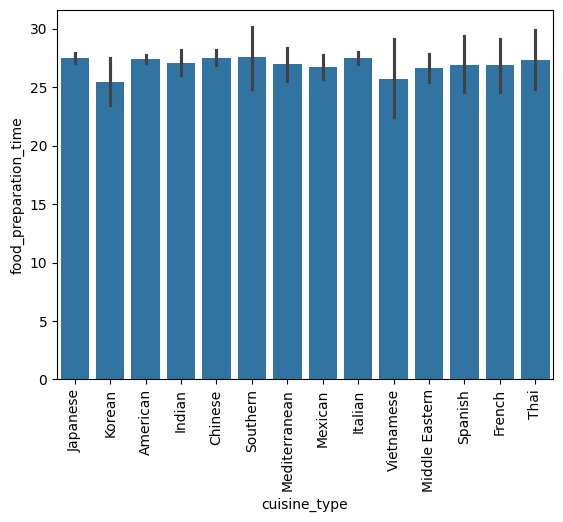

               food_preparation_time                  
                               count       mean    sum
cuisine_type                                          
American                         584  27.440068  16025
Chinese                          215  27.511628   5915
French                            18  26.888889    484
Indian                            73  27.109589   1979
Italian                          298  27.483221   8190
Japanese                         470  27.510638  12930
Korean                            13  25.461538    331
Mediterranean                     46  27.000000   1242
Mexican                           77  26.727273   2058
Middle Eastern                    49  26.673469   1307
Southern                          17  27.588235    469
Spanish                           12  26.916667    323
Thai                              19  27.315789    519
Vietnamese                         7  25.714286    180
end of section  cuisine_type  and  food_preparation_time 



cuis

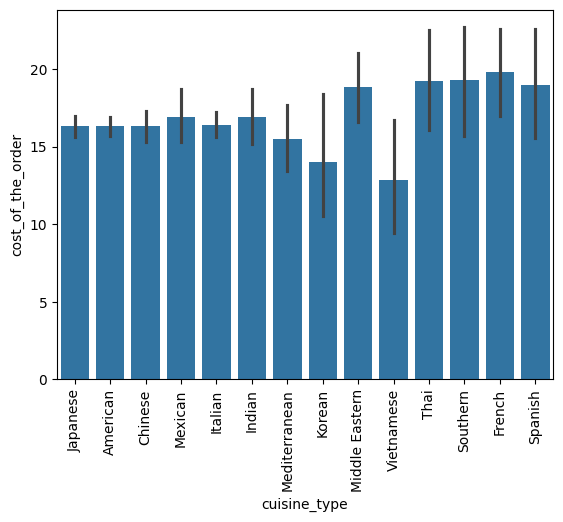

               cost_of_the_order                    
                           count       mean      sum
cuisine_type                                        
American                     584  16.319829  9530.78
Chinese                      215  16.305209  3505.62
French                        18  19.793889   356.29
Indian                        73  16.919726  1235.14
Italian                      298  16.418691  4892.77
Japanese                     470  16.304532  7663.13
Korean                        13  14.001538   182.02
Mediterranean                 46  15.474783   711.84
Mexican                       77  16.933117  1303.85
Middle Eastern                49  18.820612   922.21
Southern                      17  19.300588   328.11
Spanish                       12  18.994167   227.93
Thai                          19  19.207895   364.95
Vietnamese                     7  12.882857    90.18
end of section  cuisine_type  and  cost_of_the_order 



day_of_the_week
day_of_the_week  and  deli

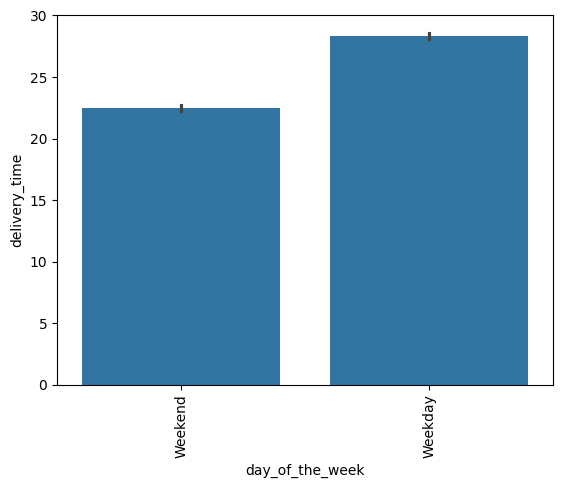

                delivery_time                  
                        count       mean    sum
day_of_the_week                                
Weekday                   547  28.340037  15502
Weekend                  1351  22.470022  30357
end of section  day_of_the_week  and  delivery_time 



day_of_the_week  and  food_preparation_time


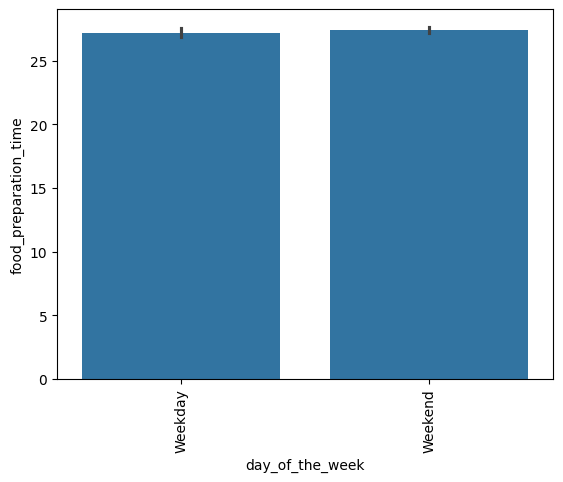

                food_preparation_time                  
                                count       mean    sum
day_of_the_week                                        
Weekday                           547  27.212066  14885
Weekend                          1351  27.436714  37067
end of section  day_of_the_week  and  food_preparation_time 



day_of_the_week  and  cost_of_the_order


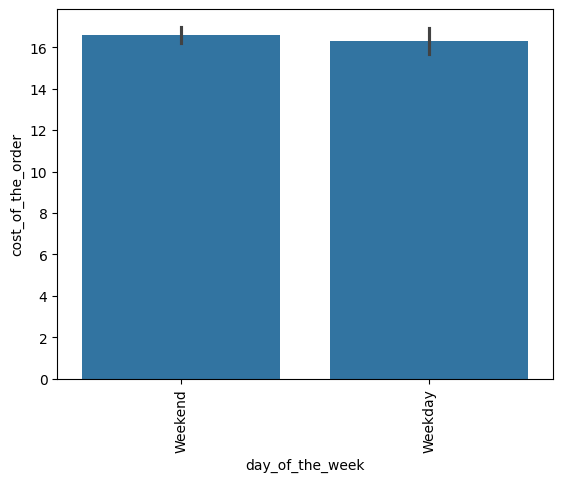

                cost_of_the_order                     
                            count       mean       sum
day_of_the_week                                       
Weekday                       547  16.311188   8922.22
Weekend                      1351  16.574833  22392.60
end of section  day_of_the_week  and  cost_of_the_order 



rating
rating  and  delivery_time


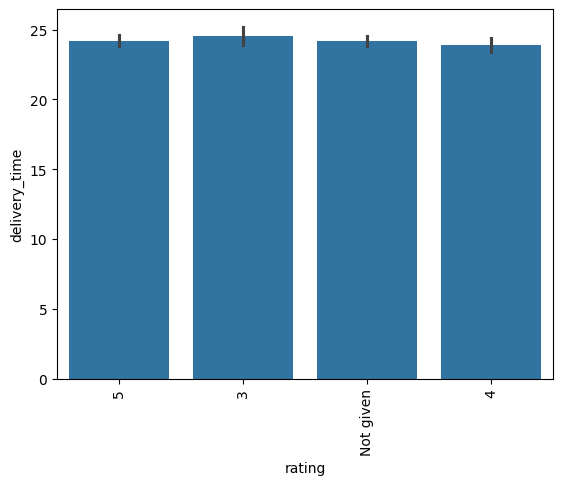

          delivery_time                  
                  count       mean    sum
rating                                   
3                   188  24.558511   4617
4                   386  23.867876   9213
5                   588  24.212585  14237
Not given           736  24.173913  17792
end of section  rating  and  delivery_time 



rating  and  food_preparation_time


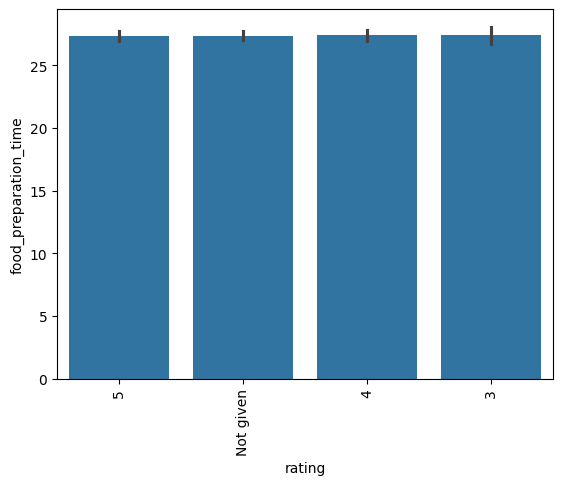

          food_preparation_time                  
                          count       mean    sum
rating                                           
3                           188  27.430851   5157
4                           386  27.396373  10575
5                           588  27.355442  16085
Not given                   736  27.357337  20135
end of section  rating  and  food_preparation_time 



rating  and  cost_of_the_order


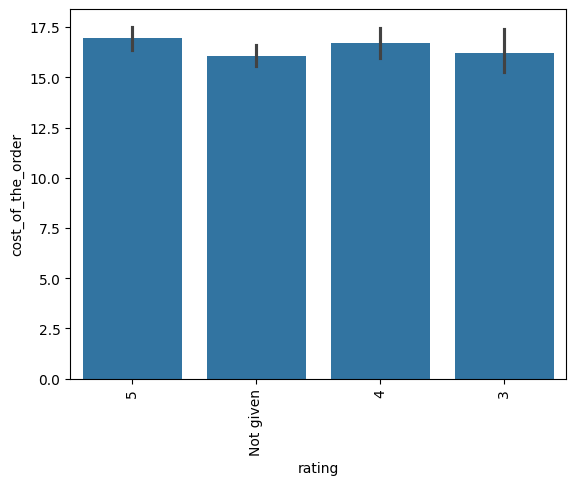

          cost_of_the_order                     
                      count       mean       sum
rating                                          
3                       188  16.223351   3049.99
4                       386  16.710337   6450.19
5                       588  16.965697   9975.83
Not given               736  16.085340  11838.81
end of section  rating  and  cost_of_the_order 





In [101]:
# loop through the heavy hitter categoires and plot the heavy hitter numerics
import warnings
warnings.filterwarnings('ignore')

numeric_cols =['delivery_time','food_preparation_time','cost_of_the_order']
category_cols= ['cuisine_type','day_of_the_week','rating']
for this in category_cols :
  print(this)
  for that in numeric_cols :
      print(this, ' and ', that )
      # sns.boxplot(data=df,x=this, y=that );
      # sns.scatterplot(data=df,x=this, y=that );
      sns.barplot(data=df.sort_values(by=that),x=this, y=that );
      locs, labels = plt.xticks()
      plt.setp(labels, rotation=90)
      plt.show()
      p_table = df.pivot_table(
                              index=this
                              #  , columns=['day_of_the_week']
                              , values=[that]
                              , aggfunc={that:['count','sum','mean']})
      print (p_table)
      print('end of section ', this, ' and ', that, '\n\n\n'  )

#### The cuisine of French, Thia and Southern have the largest average cost per order \$19.20 and up opposed to and overall average cost of \$16 for all combined cuisines.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [102]:
count_df=df.groupby(['restaurant_name'])['rating_int64'].count().rename("rating_count").reset_index(name='rating_count')
mean_df=df.groupby(['restaurant_name'])['rating_int64'].mean().rename("rating_mean").reset_index(name='rating_mean')
output_df=pd.merge(count_df, mean_df, on='restaurant_name')
output_df=output_df.sort_values(by=['rating_count'], ascending=False)
output_df.loc[(output_df['rating_count']>50 ) & (output_df['rating_mean']>4 )]

,restaurant_name,rating_count,rating_mean
134,Shake Shack,133,4.278195
151,The Meatball Shop,84,4.511905
20,Blue Ribbon Sushi,73,4.219178
19,Blue Ribbon Fried Chicken,64,4.328125


#### Observations:
* Blue Ribbon Fried Chicken
* Blue Ribbon Sushi
* The Meatball Shop
* Shake Shack are eligible for the discount offer.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [103]:
# Make a column called net_revenue_generated to calculate
#   25% on the orders having cost greater than 20 dollars
#   15% on the orders having cost greater than 5 dollars
# if cost_of_the_order >$20 then  cost_of_the_order * .25
# else if cost_of_the_order >$5 and cost_of_the_order <=$20 then then  cost_of_the_order * .15
# else 0
def calculate_net_revenue(cost):
  if cost>20 :
     net_revenue = cost * .25
  elif cost > 5 and cost <=20 :
     net_revenue = cost * .15
  else :
     net_revenue = 0
  return round(net_revenue, 2)

NewCol = df['cost_of_the_order'].apply(calculate_net_revenue)
df['company_net_revenue'] = NewCol
df.info()

# glimpse(df)

my_pivot = pd.pivot_table(df
                          , values='company_net_revenue'
                          , index=['day_of_the_week']
                          , margins = True
                          , margins_name="GRAND TOTAL REVENUE"
                          ,aggfunc=np.sum,fill_value=0)


#view pivot table
print(my_pivot)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   object 
 1   customer_id            1898 non-null   object 
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   cost_greater_than_20   1898 non-null   object 
 10  rating_int64           1162 non-null   Int64  
 11  company_net_revenue    1898 non-null   float64
dtypes: Int64(1), float64(2), int64(2), object(7)
memory usage: 179.9+ KB
                     company_net_revenue
day_of_the_week                         
Weekday  

#### Observations: Net revenue across all orders is \$6,166.50


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [104]:

# Make a column called total time that is the total time from order placement to delivery.
# Time from the customer point of view (POV)

NewCol = df['food_preparation_time'] + df['delivery_time']
df['total_time'] = NewCol
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   object 
 1   customer_id            1898 non-null   object 
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   cost_greater_than_20   1898 non-null   object 
 10  rating_int64           1162 non-null   Int64  
 11  company_net_revenue    1898 non-null   float64
 12  total_time             1898 non-null   int64  
dtypes: Int64(1), float64(2), int64(3), object(7)
memory usage: 194.7+ KB


In [105]:
def calculate_time_bucket_for_order(total_time):
  if total_time>60 :
     rtn = 'Greater than 60 minutes'
  else :
     rtn = '60 minutes or less'
  return rtn

NewCol = df['total_time'].apply(calculate_time_bucket_for_order)
df['time_bucket_for_order'] = NewCol

glimpse(df[['food_preparation_time','delivery_time','total_time' ,'time_bucket_for_order']])

glimpse shape...
1898 rows and 4 columns
glimpse head...


,food_preparation_time,delivery_time,total_time,time_bucket_for_order
0,25,20,45,60 minutes or less
1,25,23,48,60 minutes or less
2,23,28,51,60 minutes or less
3,25,15,40,60 minutes or less
4,25,24,49,60 minutes or less


glimpse sample...


,food_preparation_time,delivery_time,total_time,time_bucket_for_order
1164,20,31,51,60 minutes or less
1584,24,28,52,60 minutes or less
103,30,20,50,60 minutes or less
1754,31,33,64,Greater than 60 minutes
321,20,30,50,60 minutes or less


glimpse tail...


,food_preparation_time,delivery_time,total_time,time_bucket_for_order
1893,31,17,48,60 minutes or less
1894,31,19,50,60 minutes or less
1895,31,24,55,60 minutes or less
1896,23,31,54,60 minutes or less
1897,28,24,52,60 minutes or less


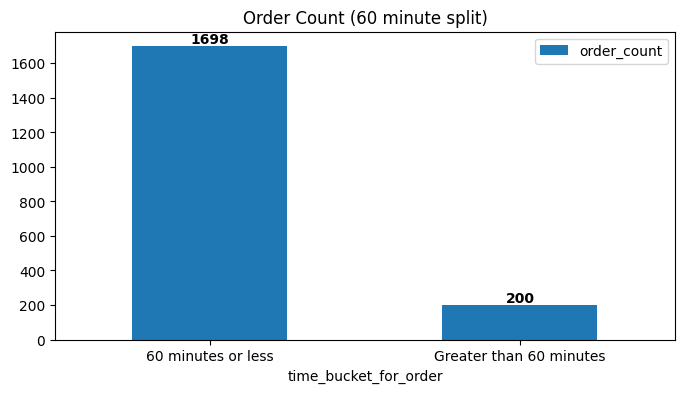

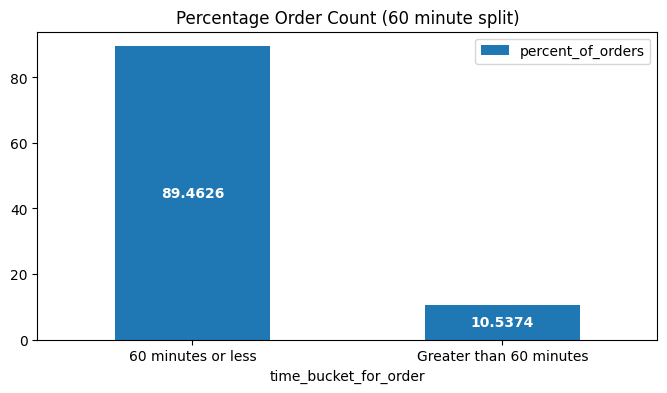

,time_bucket_for_order,order_count,percent_of_orders
0,60 minutes or less,1698,89.462592
1,Greater than 60 minutes,200,10.537408


In [106]:
sorted_df=df.groupby(['time_bucket_for_order'])['order_id'].count().rename("order_count").reset_index(name='order_count')
sorted_df=sorted_df.sort_values(by=['order_count'], ascending=False)

temp_df=df.groupby('time_bucket_for_order')['order_id'].count().rename("percentage").transform(lambda x:100 * ( x/x.sum())).reset_index(name='order_count')
temp_df = pd.merge(sorted_df, temp_df, on='time_bucket_for_order')
sorted_df = temp_df.rename(columns={'order_count_y': 'percent_of_orders', 'order_count_x': 'order_count'})

sorted_df.set_index('time_bucket_for_order').T

axe = sorted_df[['time_bucket_for_order','order_count']].plot(kind='bar',x='time_bucket_for_order', y='order_count',  stacked=False, figsize=(8,4), rot=0)

for x in axe.containers:
    axe.bar_label(x, label_type='edge', weight='bold', color='black')
    axe.set_title('Order Count (60 minute split)')
plt.show()

axe = sorted_df[['time_bucket_for_order','percent_of_orders']].plot(kind='bar',x='time_bucket_for_order', y='percent_of_orders',  stacked=False, figsize=(8,4), rot=0)
for x in axe.containers:
    axe.bar_label(x, label_type='center', weight='bold', color='white')
    axe.set_title('Percentage Order Count (60 minute split)')
plt.show()
sorted_df.head(3)

#### Observations: 10.5% (200) of the 1,898 orders take longer than 60 minutes to deliver.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: delivery_time
Non-Null Count  Dtype
--------------  -----
1898 non-null   int64
dtypes: int64(1)
memory usage: 15.0 KB


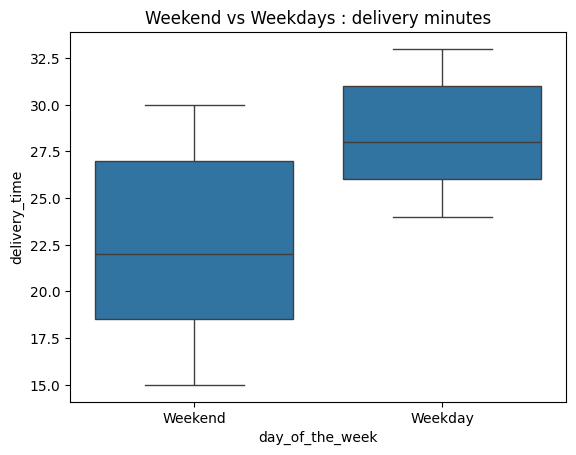

,mean_delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


In [107]:
df['delivery_time'].info()
left_df = df.groupby(['day_of_the_week'])['delivery_time'].mean().rename("mean_delivery_time")
# right_df = df.groupby(['day_of_the_week'])['delivery_time'].count().rename("order_count")
# sorted_df=pd.merge( left_df, right_df, on='day_of_the_week')
# sorted_df.set_index('mean_delivery_time').T

# axe = sorted_df.plot(kind='bar' )
# for x in axe.containers:
#     axe.bar_label(x, label_type='edge', weight='bold', color='black')
#     axe.set_title('Weekend vs Weekdays : orders and delivery minutes')
# plt.show()

axe = sns.boxplot(data=df
            ,x='day_of_the_week'
            ,y='delivery_time'
            ,showfliers=False # showfliers parameter controls the representation of outliers in the boxplot
            ).set(title='Weekend vs Weekdays : delivery minutes');

plt.show()

left_df

#### Observations:
While 71% of order volumr occurs on Weekends we find that the average delivery time is significatly lower. On average , weekend delivery time takes 22.47 minutes (approx 22 minutes 30 seconds ) While weekday delivery time takes 28.35 minutes ( approx 28 minutes and 21 seconds).

This is most likely attributable to
1. Higher staffing on weekend
2. Lower traffic ( fewer obstavcles to delivery) as people tend to be home on weekend
3. Economies of scale as higher volume tends to mean easier production

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

In [108]:
n_orders = len(df)
gross = df["cost_of_the_order"].sum()
commission = df["company_net_revenue"].sum()
print("Orders:", n_orders)
print("Gross order value: $", round(gross, 2))
print("Company commission: $", round(commission, 2))
print("Commission per order: $", round(commission / n_orders, 2))

Orders: 1898
Gross order value: $ 31314.82
Company commission: $ 6166.5
Commission per order: $ 3.25


### Conclusions

- **1,898 orders** in the file (not 1,198).
- Company commission is **\$6,166.50** across all orders (about **\$3.25** per order). Use the printed gross from the cell above; do not hard-code \$31,314.82.
- Demand is weekend-heavy. Weekday deliveries run slower (~28.3 min vs ~22.5 min).
- Feedback is thin: **39% of orders have no rating**.
- About **10.5%** of orders take more than 60 minutes end-to-end (prep + delivery).



### Recommendations

- Target an average rating of 4 or better, and cut the 39% “Not given” rate with a small coupon or bonus for a rating.
- Revisit the \$5 / \$20 commission tiers. The cost distribution suggests another natural cut near \$30.
- Treat total time (prep + delivery) as the customer clock. Cap service area or menu breadth where total time runs long; consider a minimum order for low-volume, distant restaurants.
- Keep cultivating the four promo-ready partners (Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken) without ignoring smaller cuisines.